<a href="https://colab.research.google.com/github/clee2026/MSDS_498/blob/main/capstone/eda/nyc_311_eda_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/clee2026/MSDS_498/blob/main/capstone/eda/nyc_311_eda_notebook_combined_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC 311 EDA Notebook

This Colab-ready notebook supports three data sources with the same downstream EDA flow:
- API pull from NYC Open Data
- Parquet file
- CSV file

This EDA is designed to help the team answer questions such as:
- Where are response times longest
- Which complaint categories drive the most volume
- Which boroughs or agencies appear slower than others
- Whether there are patterns by time, channel, or repeated complaint behavior

For large files in Colab, Google Drive is usually the easiest setup. The notebook can mount Drive and read Parquet or CSV directly from there.


Testing the mount drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/project_data/Capstone Course Project Files/Data"

'311_ServiceRequest_2020-present_DataDictionary_Updated_2025 (1).xlsx'
 nyc_311_all_appended.parquet
 nyc_311_batches


**EDA**

In [3]:
# 1. Imports

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

OUTPUT_DIR = Path("outputs_311_eda")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Output folder:", OUTPUT_DIR.resolve())


Output folder: /content/outputs_311_eda


In [4]:
# 2. Configuration

# Change these settings as needed for your analysis.

# Choose one:
# - "api"     -> pull from official NYC Open Data API
# - "parquet" -> read from a Parquet file
# - "csv"     -> read from a CSV file
DATA_SOURCE = "parquet"


# Colab / Google Drive settings
# Recommended for large Parquet or CSV files.
USE_GOOGLE_DRIVE = True
MOUNT_GOOGLE_DRIVE = True
DRIVE_MOUNT_POINT = "/content/drive"
DRIVE_DATA_DIR = f"{DRIVE_MOUNT_POINT}/MyDrive/project_data/Capstone Course Project Files/Data"

# If using Google Drive, update these to your actual Drive file names/paths.
DRIVE_PARQUET_PATH = f"{DRIVE_DATA_DIR}/nyc_311_all_appended.parquet"
# For the Parquet folder
# DRIVE_PARQUET_PATH = f"{DRIVE_DATA_DIR}/nyc_311_batches"
DRIVE_CSV_PATH = f"{DRIVE_DATA_DIR}/311_Service_Requests_from_2020_to_Present.csv"
DRIVE_DATA_DICTIONARY_PATH = f"{DRIVE_DATA_DIR}/311_ServiceRequest_2020-present_DataDictionary_Updated_2025 (1).xlsx"


# Local runtime / uploaded file settings
# Use these when files are uploaded directly into Colab runtime.
LOCAL_PARQUET_PATH = "311_Service_Requests_from_2020_to_Present.parquet"
LOCAL_CSV_PATH = "311_Service_Requests_from_2020_to_Present.csv"
LOCAL_DATA_DICTIONARY_PATH = "311_ServiceRequest_2020-present_DataDictionary_Updated_2025.xlsx"


# API settings
API_BASE = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

# The API defaults to 1,000 rows if $limit is not specified.
# Start smaller for testing, then raise if needed.
API_LIMIT = 100000


# Development / runtime controls
# Optional row limit after reading data. Use None for all rows returned/read.
ROW_LIMIT = None   # Example: 10000

# Time window
# These can be changed. Start with a recent range to keep runtime manageable.
START_DATE = "2023-01-01"
END_DATE = None   # Example: "2024-12-31"

# Geography filter
# Use [] to mean "all boroughs"
# Example: ["BROOKLYN", "QUEENS"]
BOROUGHS = []

# Complaint type filter
# Use [] to mean "all complaint types"
# Example: ["Noise - Residential", "Illegal Parking"]
PROBLEMS = []

# Keep only a focused set of columns based on the data dictionary.
EXPECTED_COLUMNS = [
    "unique_key",
    "created_date",
    "closed_date",
    "agency",
    "agency_name",
    "problem",
    "problem_detail",
    "additional_details",
    "status",
    "due_date",
    "resolution_action_updated_date",
    "resolution_description",
    "location_type",
    "incident_zip",
    "incident_address",
    "street_name",
    "cross_street_1",
    "cross_street_2",
    "intersection_street_1",
    "intersection_street_2",
    "address_type",
    "city",
    "landmark",
    "facility_type",
    "community_board",
    "council_district",
    "police_precinct",
    "bbl",
    "borough",
    "x_coordinate_state_plane",
    "y_coordinate_state_plane",
    "open_data_channel_type",
    "latitude",
    "longitude",
    "location",
    "park_facility_name",
    "park_borough",
    "vehicle_type",
    "taxi_company_borough",
    "taxi_pick_up_location",
    "bridge_highway_name",
    "bridge_highway_direction",
    "road_ramp",
    "bridge_highway_segment",
]

print("Configured source:", DATA_SOURCE)
print("Use Google Drive:", USE_GOOGLE_DRIVE)
print("Expected columns:", len(EXPECTED_COLUMNS))


Configured source: parquet
Use Google Drive: True
Expected columns: 44


In [5]:
# 3. Helper functions

from urllib.parse import urlencode

def running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def maybe_mount_google_drive():
    if not USE_GOOGLE_DRIVE or not MOUNT_GOOGLE_DRIVE:
        return

    if not running_in_colab():
        print("Google Drive mount skipped because this environment is not Colab.")
        return

    try:
        from google.colab import drive
        drive.mount(DRIVE_MOUNT_POINT, force_remount=False)
    except Exception as e:
        print("Google Drive mount was not completed:", e)

def resolve_data_path(local_path: str, drive_path: str) -> Path:
    if USE_GOOGLE_DRIVE:
        return Path(drive_path)
    return Path(local_path)

def get_data_dictionary_path() -> Path:
    return resolve_data_path(LOCAL_DATA_DICTIONARY_PATH, DRIVE_DATA_DICTIONARY_PATH)

def normalize_column_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")

def build_api_url():
    # URL-encode query parameters so spaces and special characters
    # in the $where clause do not break the API call.
    params = {
        "$limit": API_LIMIT
    }

    where_clauses = []

    if START_DATE:
        where_clauses.append(f"created_date >= '{START_DATE}T00:00:00'")
    if END_DATE:
        where_clauses.append(f"created_date <= '{END_DATE}T23:59:59'")

    if BOROUGHS:
        borough_sql = ", ".join([f"'{b}'" for b in BOROUGHS])
        where_clauses.append(f"borough in ({borough_sql})")

    if PROBLEMS:
        # The public API typically uses complaint_type even if the
        # later notebook logic standardizes to "problem".
        problem_sql = ", ".join([f"'{p}'" for p in PROBLEMS])
        where_clauses.append(f"complaint_type in ({problem_sql})")

    if where_clauses:
        params["$where"] = " AND ".join(where_clauses)

    return API_BASE + "?" + urlencode(params)

def apply_filters(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Standardize column names first so downstream filters are consistent.
    df.columns = [normalize_column_name(c) for c in df.columns]

    # Handle older field names if needed before filtering.
    rename_map = {}
    if "complaint_type" in df.columns and "problem" not in df.columns:
        rename_map["complaint_type"] = "problem"
    if "descriptor" in df.columns and "problem_detail" not in df.columns:
        rename_map["descriptor"] = "problem_detail"
    if rename_map:
        df = df.rename(columns=rename_map)

    # Date filter
    if "created_date" in df.columns:
        created_dt = pd.to_datetime(df["created_date"], errors="coerce")

        if START_DATE:
            df = df.loc[created_dt >= pd.to_datetime(START_DATE)].copy()
            created_dt = pd.to_datetime(df["created_date"], errors="coerce")

        if END_DATE:
            end_ts = pd.to_datetime(END_DATE) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
            df = df.loc[created_dt <= end_ts].copy()

    # Borough filter
    if BOROUGHS and "borough" in df.columns:
        borough_set = {str(b).upper() for b in BOROUGHS}
        df = df.loc[df["borough"].astype(str).str.upper().isin(borough_set)].copy()

    # Problem filter
    if PROBLEMS and "problem" in df.columns:
        problem_set = {str(p) for p in PROBLEMS}
        df = df.loc[df["problem"].astype(str).isin(problem_set)].copy()

    if ROW_LIMIT is not None:
        df = df.head(ROW_LIMIT).copy()

    return df

def load_data():
    source = DATA_SOURCE.lower().strip()

    if source in {"parquet", "csv"}:
        maybe_mount_google_drive()

    if source == "api":
        url = build_api_url()
        print("Reading from API:")
        print(url)
        df = pd.read_csv(url)

    elif source == "parquet":
        parquet_path = resolve_data_path(LOCAL_PARQUET_PATH, DRIVE_PARQUET_PATH)
        print("Reading Parquet:", parquet_path)
        df = pd.read_parquet(parquet_path)

    elif source == "csv":
        csv_path = resolve_data_path(LOCAL_CSV_PATH, DRIVE_CSV_PATH)
        print("Reading CSV:", csv_path)
        df = pd.read_csv(csv_path, low_memory=False)

    else:
        raise ValueError("DATA_SOURCE must be 'api', 'parquet', or 'csv'.")

    df = apply_filters(df)
    return df

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [normalize_column_name(c) for c in df.columns]
    return df

def save_table(df: pd.DataFrame, file_name: str):
    path = OUTPUT_DIR / file_name
    df.to_csv(path, index=False)
    print("Saved:", path)

def save_plot(file_name: str):
    path = OUTPUT_DIR / file_name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


In [6]:
# 4. Optional: read the data dictionary workbook

# This cell is optional. It reads the data dictionary if the workbook
# is present and shows the documented column names and descriptions.

dictionary_df = None

DATA_DICTIONARY_PATH = get_data_dictionary_path()

if Path(DATA_DICTIONARY_PATH).exists():
    dictionary_df = pd.read_excel(DATA_DICTIONARY_PATH, sheet_name="Column Information", header=1)
    dictionary_df.columns = ["column_name", "description", "format", "valid_values", "notes"]
    dictionary_df = dictionary_df.iloc[1:].reset_index(drop=True)
    dictionary_df["column_name_clean"] = (
        dictionary_df["column_name"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    print("Loaded data dictionary workbook.")
    display(dictionary_df[["column_name", "column_name_clean", "description"]].head(15))
else:
    print("Data dictionary workbook not found in the current working directory. The notebook can still run using the hardcoded expected fields.")


Loaded data dictionary workbook.


,column_name,column_name_clean,description
0,Unique Key,unique_key,Unique identifier of a Service Request (SR) in...
1,Created Date,created_date,The date and time that a Customer submits a Se...
2,Closed Date,closed_date,The date and time that an Agency closes a Serv...
3,Agency,agency,Acronym of responding City Government Agency o...
4,Agency Name,agency_name,Full agency name of responding City Government...
5,Problem,problem,This is the first level of a hierarchy identif...
6,Problem Detail,problem_detail,A second level of detail about the Problem (fo...
7,Additional Details,additional_details,A third level of detail about the Problem (for...
8,Status,status,Current status of the service request submitted\n
9,Due Date,due_date,Date when responding agency is expected to upd...


In [7]:
# 5. Load the data

df_raw = load_data()
print("Raw shape after source read and filters:", df_raw.shape)
display(df_raw.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading Parquet: /content/drive/MyDrive/project_data/Capstone Course Project Files/Data/nyc_311_all_appended.parquet
Raw shape after source read and filters: (3300000, 45)


,unique_key,created_date,closed_date,agency,agency_name,problem,problem_detail,descriptor_2,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,status,due_date,resolution_description,resolution_action_updated_date,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location,source_parquet
0,68555060,2026-04-04T02:55:19.000,None,DOT,Department of Transportation,Street Condition,Pothole,None,None,11378.0,None,None,None,None,56 ROAD,RUST STREET,INTERSECTION,QUEENS,None,None,Open,None,The Department of Transportation referred this...,2026-04-04T02:55:19.000,02 QUEENS,26.0,Precinct 108,NaN,QUEENS,1007781.0,203222.0,UNKNOWN,Unspecified,QUEENS,None,None,None,None,None,None,None,40.724443,-73.915105,POINT (-73.915105438895 40.724442854308),batch_0.parquet
1,68557159,2026-04-04T02:54:42.000,2026-04-04T02:54:42.000,DOT,Department of Transportation,Street Condition,Pothole,None,None,11377.0,None,None,None,None,59 STREET,QUEENS BOULEVARD,INTERSECTION,QUEENS,None,None,Closed,None,The Department of Transportation determined th...,2026-04-04T02:54:42.000,02 QUEENS,26.0,Precinct 108,NaN,QUEENS,1010206.0,209517.0,UNKNOWN,Unspecified,QUEENS,None,None,None,None,None,None,None,40.741714,-73.906332,POINT (-73.906332305295 40.741714289155),batch_0.parquet
2,68549835,2026-04-04T02:25:42.000,None,DOT,Department of Transportation,Street Condition,Pothole,None,None,11416.0,None,None,None,None,101 AVENUE,WOODHAVEN BOULEVARD,INTERSECTION,QUEENS,None,None,Open,None,The Department of Transportation referred this...,2026-04-04T02:25:42.000,09 QUEENS,32.0,Precinct 102,NaN,QUEENS,1026935.0,188601.0,UNKNOWN,Unspecified,QUEENS,None,None,None,None,None,None,None,40.684240,-73.846095,POINT (-73.846094899193 40.684240023102),batch_0.parquet
3,68551639,2026-04-04T02:21:21.000,None,DSNY,Department of Sanitation,Graffiti,Graffiti,None,Mixed Use,10003.0,241 EAST 10 STREET,EAST 10 STREET,None,None,None,None,ADDRESS,NEW YORK,None,None,Open,2026-05-04T02:21:21.000,The graffiti on this property has been schedul...,2026-04-04T02:21:21.000,03 MANHATTAN,2.0,Precinct 9,1.004520e+09,MANHATTAN,988445.0,204857.0,UNKNOWN,Unspecified,MANHATTAN,None,None,None,None,None,None,None,40.728961,-73.984864,POINT (-73.984864358716 40.728960833715),batch_0.parquet
4,68551885,2026-04-04T02:01:53.000,2026-04-04T02:01:53.000,DOT,Department of Transportation,Street Condition,Pothole,None,None,11237.0,None,None,None,None,GATES AVENUE,WYCKOFF AVENUE,INTERSECTION,BROOKLYN,None,None,Closed,None,The Department of Transportation determined th...,2026-04-04T02:01:53.000,04 BROOKLYN,37.0,Precinct 83,NaN,BROOKLYN,1008704.0,194295.0,UNKNOWN,Unspecified,BROOKLYN,None,None,None,None,None,None,None,40.699938,-73.911808,POINT (-73.911807889798 40.699937873372),batch_0.parquet


In [8]:
# 6. Standardize column names and compare with the data dictionary

df = standardize_columns(df_raw)

available_cols = sorted(df.columns.tolist())
expected_set = set(EXPECTED_COLUMNS)
available_set = set(available_cols)

matched_cols = sorted(expected_set.intersection(available_set))
missing_from_data = sorted(expected_set - available_set)
extra_in_data = sorted(available_set - expected_set)

print(f"Columns in data: {len(available_cols)}")
print(f"Matched expected columns: {len(matched_cols)}")
print(f"Missing expected columns: {len(missing_from_data)}")
print(f"Extra columns in data: {len(extra_in_data)}")

comparison_df = pd.DataFrame({
    "matched_columns": pd.Series(matched_cols),
    "missing_expected_columns": pd.Series(missing_from_data),
    "extra_columns_in_data": pd.Series(extra_in_data),
})
display(comparison_df.head(50))
save_table(comparison_df, "column_dictionary_comparison.csv")


Columns in data: 45
Matched expected columns: 43
Missing expected columns: 1
Extra columns in data: 2


,matched_columns,missing_expected_columns,extra_columns_in_data
0,address_type,additional_details,descriptor_2
1,agency,NaN,source_parquet
2,agency_name,NaN,NaN
3,bbl,NaN,NaN
4,borough,NaN,NaN
5,bridge_highway_direction,NaN,NaN
6,bridge_highway_name,NaN,NaN
7,bridge_highway_segment,NaN,NaN
8,city,NaN,NaN
9,closed_date,NaN,NaN


Saved: outputs_311_eda/column_dictionary_comparison.csv


In [9]:
# 7. Keep relevant columns and parse dates

# A few public versions still use the old names complaint_type / descriptor.
# This renames them into the current dictionary names where needed.

rename_map = {}
if "complaint_type" in df.columns and "problem" not in df.columns:
    rename_map["complaint_type"] = "problem"
if "descriptor" in df.columns and "problem_detail" not in df.columns:
    rename_map["descriptor"] = "problem_detail"

df = df.rename(columns=rename_map)

core_cols = [c for c in EXPECTED_COLUMNS if c in df.columns]
df = df[core_cols].copy()

date_cols = [
    "created_date",
    "closed_date",
    "due_date",
    "resolution_action_updated_date",
]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Basic numeric parsing for coordinates / districts if present
for c in ["latitude", "longitude", "council_district", "police_precinct"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Working shape:", df.shape)
display(df.head())


Working shape: (3300000, 43)


,unique_key,created_date,closed_date,agency,agency_name,problem,problem_detail,status,due_date,resolution_action_updated_date,resolution_description,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,latitude,longitude,location,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment
0,68555060,2026-04-04 02:55:19,NaT,DOT,Department of Transportation,Street Condition,Pothole,Open,NaT,2026-04-04 02:55:19,The Department of Transportation referred this...,None,11378.0,None,None,None,None,56 ROAD,RUST STREET,INTERSECTION,QUEENS,None,None,02 QUEENS,26.0,NaN,NaN,QUEENS,1007781.0,203222.0,UNKNOWN,40.724443,-73.915105,POINT (-73.915105438895 40.724442854308),Unspecified,QUEENS,None,None,None,None,None,None,None
1,68557159,2026-04-04 02:54:42,2026-04-04 02:54:42,DOT,Department of Transportation,Street Condition,Pothole,Closed,NaT,2026-04-04 02:54:42,The Department of Transportation determined th...,None,11377.0,None,None,None,None,59 STREET,QUEENS BOULEVARD,INTERSECTION,QUEENS,None,None,02 QUEENS,26.0,NaN,NaN,QUEENS,1010206.0,209517.0,UNKNOWN,40.741714,-73.906332,POINT (-73.906332305295 40.741714289155),Unspecified,QUEENS,None,None,None,None,None,None,None
2,68549835,2026-04-04 02:25:42,NaT,DOT,Department of Transportation,Street Condition,Pothole,Open,NaT,2026-04-04 02:25:42,The Department of Transportation referred this...,None,11416.0,None,None,None,None,101 AVENUE,WOODHAVEN BOULEVARD,INTERSECTION,QUEENS,None,None,09 QUEENS,32.0,NaN,NaN,QUEENS,1026935.0,188601.0,UNKNOWN,40.684240,-73.846095,POINT (-73.846094899193 40.684240023102),Unspecified,QUEENS,None,None,None,None,None,None,None
3,68551639,2026-04-04 02:21:21,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,Open,2026-05-04 02:21:21,2026-04-04 02:21:21,The graffiti on this property has been schedul...,Mixed Use,10003.0,241 EAST 10 STREET,EAST 10 STREET,None,None,None,None,ADDRESS,NEW YORK,None,None,03 MANHATTAN,2.0,NaN,1.004520e+09,MANHATTAN,988445.0,204857.0,UNKNOWN,40.728961,-73.984864,POINT (-73.984864358716 40.728960833715),Unspecified,MANHATTAN,None,None,None,None,None,None,None
4,68551885,2026-04-04 02:01:53,2026-04-04 02:01:53,DOT,Department of Transportation,Street Condition,Pothole,Closed,NaT,2026-04-04 02:01:53,The Department of Transportation determined th...,None,11237.0,None,None,None,None,GATES AVENUE,WYCKOFF AVENUE,INTERSECTION,BROOKLYN,None,None,04 BROOKLYN,37.0,NaN,NaN,BROOKLYN,1008704.0,194295.0,UNKNOWN,40.699938,-73.911808,POINT (-73.911807889798 40.699937873372),Unspecified,BROOKLYN,None,None,None,None,None,None,None


In [10]:
# 8. Create business-ready engineered fields

if "created_date" in df.columns:
    df["created_year"] = df["created_date"].dt.year
    df["created_month"] = df["created_date"].dt.month
    df["created_month_name"] = df["created_date"].dt.month_name()
    df["created_dayofweek"] = df["created_date"].dt.day_name()
    df["created_hour"] = df["created_date"].dt.hour

if {"created_date", "closed_date"}.issubset(df.columns):
    df["response_time_hours"] = (df["closed_date"] - df["created_date"]).dt.total_seconds() / 3600
    df["response_time_days"] = df["response_time_hours"] / 24

# Delay flag based on whether the request missed the due date.
if {"closed_date", "due_date"}.issubset(df.columns):
    df["delay_flag_due_date"] = np.where(
        (df["closed_date"].notna()) & (df["due_date"].notna()) & (df["closed_date"] > df["due_date"]),
        1, 0
    )

# Simple repeat complaint candidate:
# same zip + problem + created date bucket.
repeat_keys = [c for c in ["incident_zip", "problem"] if c in df.columns]
if repeat_keys:
    df["created_date_only"] = df["created_date"].dt.date if "created_date" in df.columns else pd.NaT
    group_cols = repeat_keys + (["created_date_only"] if "created_date_only" in df.columns else [])
    df["possible_repeat_count"] = df.groupby(group_cols)["unique_key"].transform("count") if "unique_key" in df.columns else df.groupby(group_cols)[group_cols[0]].transform("count")

display(df.head())


,unique_key,created_date,closed_date,agency,agency_name,problem,problem_detail,status,due_date,resolution_action_updated_date,resolution_description,location_type,incident_zip,incident_address,street_name,cross_street_1,cross_street_2,intersection_street_1,intersection_street_2,address_type,city,landmark,facility_type,community_board,council_district,police_precinct,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,latitude,longitude,location,park_facility_name,park_borough,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,created_year,created_month,created_month_name,created_dayofweek,created_hour,response_time_hours,response_time_days,delay_flag_due_date,created_date_only,possible_repeat_count
0,68555060,2026-04-04 02:55:19,NaT,DOT,Department of Transportation,Street Condition,Pothole,Open,NaT,2026-04-04 02:55:19,The Department of Transportation referred this...,None,11378.0,None,None,None,None,56 ROAD,RUST STREET,INTERSECTION,QUEENS,None,None,02 QUEENS,26.0,NaN,NaN,QUEENS,1007781.0,203222.0,UNKNOWN,40.724443,-73.915105,POINT (-73.915105438895 40.724442854308),Unspecified,QUEENS,None,None,None,None,None,None,None,2026,4,April,Saturday,2,NaN,NaN,0,2026-04-04,1.0
1,68557159,2026-04-04 02:54:42,2026-04-04 02:54:42,DOT,Department of Transportation,Street Condition,Pothole,Closed,NaT,2026-04-04 02:54:42,The Department of Transportation determined th...,None,11377.0,None,None,None,None,59 STREET,QUEENS BOULEVARD,INTERSECTION,QUEENS,None,None,02 QUEENS,26.0,NaN,NaN,QUEENS,1010206.0,209517.0,UNKNOWN,40.741714,-73.906332,POINT (-73.906332305295 40.741714289155),Unspecified,QUEENS,None,None,None,None,None,None,None,2026,4,April,Saturday,2,0.0,0.0,0,2026-04-04,1.0
2,68549835,2026-04-04 02:25:42,NaT,DOT,Department of Transportation,Street Condition,Pothole,Open,NaT,2026-04-04 02:25:42,The Department of Transportation referred this...,None,11416.0,None,None,None,None,101 AVENUE,WOODHAVEN BOULEVARD,INTERSECTION,QUEENS,None,None,09 QUEENS,32.0,NaN,NaN,QUEENS,1026935.0,188601.0,UNKNOWN,40.684240,-73.846095,POINT (-73.846094899193 40.684240023102),Unspecified,QUEENS,None,None,None,None,None,None,None,2026,4,April,Saturday,2,NaN,NaN,0,2026-04-04,1.0
3,68551639,2026-04-04 02:21:21,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,Open,2026-05-04 02:21:21,2026-04-04 02:21:21,The graffiti on this property has been schedul...,Mixed Use,10003.0,241 EAST 10 STREET,EAST 10 STREET,None,None,None,None,ADDRESS,NEW YORK,None,None,03 MANHATTAN,2.0,NaN,1.004520e+09,MANHATTAN,988445.0,204857.0,UNKNOWN,40.728961,-73.984864,POINT (-73.984864358716 40.728960833715),Unspecified,MANHATTAN,None,None,None,None,None,None,None,2026,4,April,Saturday,2,NaN,NaN,0,2026-04-04,1.0
4,68551885,2026-04-04 02:01:53,2026-04-04 02:01:53,DOT,Department of Transportation,Street Condition,Pothole,Closed,NaT,2026-04-04 02:01:53,The Department of Transportation determined th...,None,11237.0,None,None,None,None,GATES AVENUE,WYCKOFF AVENUE,INTERSECTION,BROOKLYN,None,None,04 BROOKLYN,37.0,NaN,NaN,BROOKLYN,1008704.0,194295.0,UNKNOWN,40.699938,-73.911808,POINT (-73.911807889798 40.699937873372),Unspecified,BROOKLYN,None,None,None,None,None,None,None,2026,4,April,Saturday,2,0.0,0.0,0,2026-04-04,1.0


,column,null_count,null_pct,dtype
25,police_precinct,3300000,1.000000,float64
37,taxi_company_borough,3297626,0.999281,object
22,facility_type,3290788,0.997208,object
41,road_ramp,3290345,0.997074,object
40,bridge_highway_direction,3289366,0.996778,object
8,due_date,3287046,0.996075,datetime64[ns]
42,bridge_highway_segment,3282115,0.994580,object
39,bridge_highway_name,3282062,0.994564,object
38,taxi_pick_up_location,3268861,0.990564,object
36,vehicle_type,3161159,0.957927,object


Saved: outputs_311_eda/data_quality_summary.csv
Saved: outputs_311_eda/missingness_top15.png


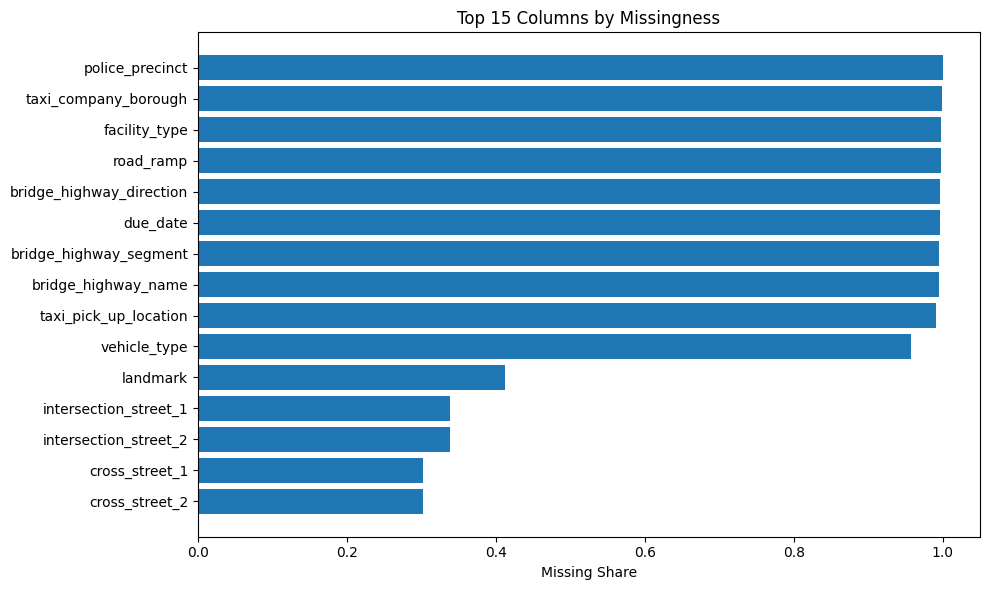

In [11]:
# 9. Data quality review

nulls = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={"index": "column", 0: "null_count"})
)
nulls["null_pct"] = nulls["null_count"] / len(df)

dtype_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes]
})

quality_df = nulls.merge(dtype_df, on="column", how="left").sort_values("null_pct", ascending=False)
display(quality_df.head(30))
save_table(quality_df, "data_quality_summary.csv")

plt.figure(figsize=(10, 6))
plot_df = quality_df.head(15).sort_values("null_pct", ascending=True)
plt.barh(plot_df["column"], plot_df["null_pct"])
plt.title("Top 15 Columns by Missingness")
plt.xlabel("Missing Share")
save_plot("missingness_top15.png")


In [12]:
# 10. Executive KPI summary

kpi = {}

kpi["rows"] = len(df)
kpi["unique_requests"] = df["unique_key"].nunique() if "unique_key" in df.columns else np.nan
kpi["avg_response_hours"] = df["response_time_hours"].mean() if "response_time_hours" in df.columns else np.nan
kpi["median_response_hours"] = df["response_time_hours"].median() if "response_time_hours" in df.columns else np.nan
kpi["open_share"] = (df["status"].astype(str).str.upper().eq("OPEN").mean() if "status" in df.columns else np.nan)
kpi["closed_share"] = (df["status"].astype(str).str.upper().eq("CLOSED").mean() if "status" in df.columns else np.nan)
kpi["delayed_share_due_date"] = (df["delay_flag_due_date"].mean() if "delay_flag_due_date" in df.columns else np.nan)

kpi_df = pd.DataFrame(list(kpi.items()), columns=["metric", "value"])
display(kpi_df)
save_table(kpi_df, "kpi_summary.csv")


,metric,value
0,rows,3.300000e+06
1,unique_requests,3.274374e+06
2,avg_response_hours,1.334961e+02
3,median_response_hours,5.885000e+00
4,open_share,2.602545e-02
5,closed_share,9.452409e-01
6,delayed_share_due_date,8.448485e-04


Saved: outputs_311_eda/kpi_summary.csv


,problem,request_count
0,Illegal Parking,501365
1,Noise - Residential,369414
2,HEAT/HOT WATER,329068
3,Blocked Driveway,161274
4,Noise - Street/Sidewalk,144663
5,UNSANITARY CONDITION,108095
6,Street Condition,82148
7,Water System,75661
8,PLUMBING,67233
9,Snow or Ice,63938


Saved: outputs_311_eda/top_problem_counts.csv
Saved: outputs_311_eda/top_problem_categories.png


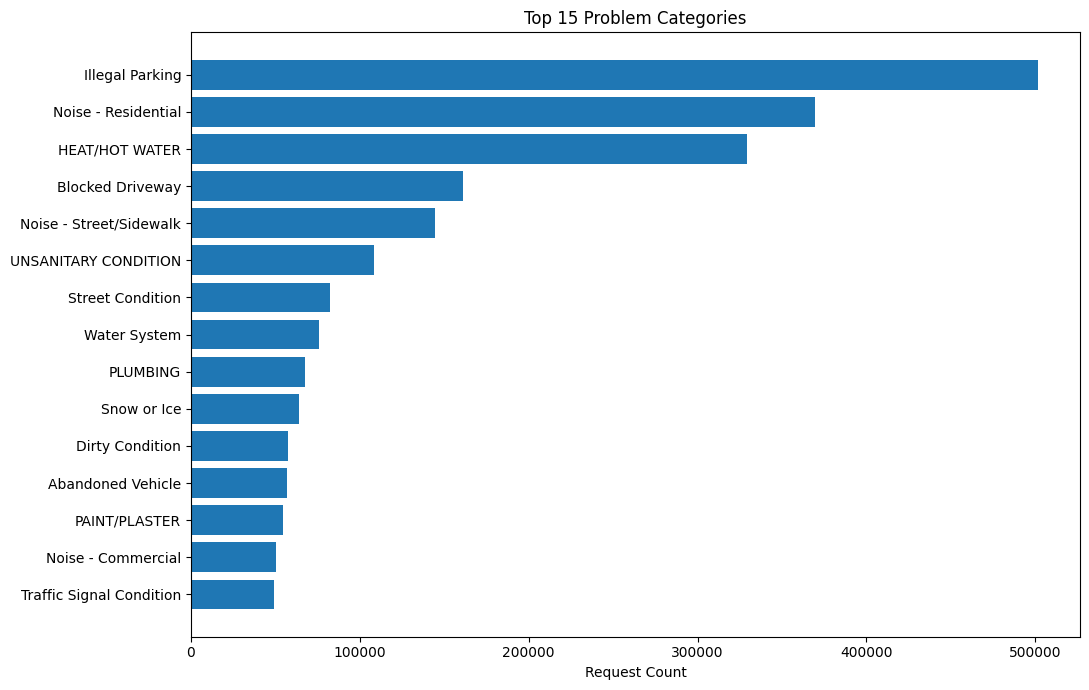

In [13]:
# 11. Complaint mix: top problems

if "problem" in df.columns:
    top_problem = (
        df["problem"]
        .fillna("Unknown")
        .value_counts()
        .reset_index()
    )
    top_problem.columns = ["problem", "request_count"]
    display(top_problem.head(20))
    save_table(top_problem, "top_problem_counts.csv")

    plt.figure(figsize=(11, 7))
    plot_df = top_problem.head(15).sort_values("request_count", ascending=True)
    plt.barh(plot_df["problem"], plot_df["request_count"])
    plt.title("Top 15 Problem Categories")
    plt.xlabel("Request Count")
    save_plot("top_problem_categories.png")
else:
    print("Column 'problem' not available.")


,borough,request_count,avg_response_hours,median_response_hours
1,BROOKLYN,977056,128.221966,6.500000
3,QUEENS,807696,129.921094,3.590000
0,BRONX,729497,127.587348,7.713611
2,MANHATTAN,648048,152.772668,8.712500
4,STATEN ISLAND,135166,128.642327,9.505972
5,Unspecified,2537,518.934054,66.565000


Saved: outputs_311_eda/borough_performance.csv
Saved: outputs_311_eda/avg_response_time_by_borough.png


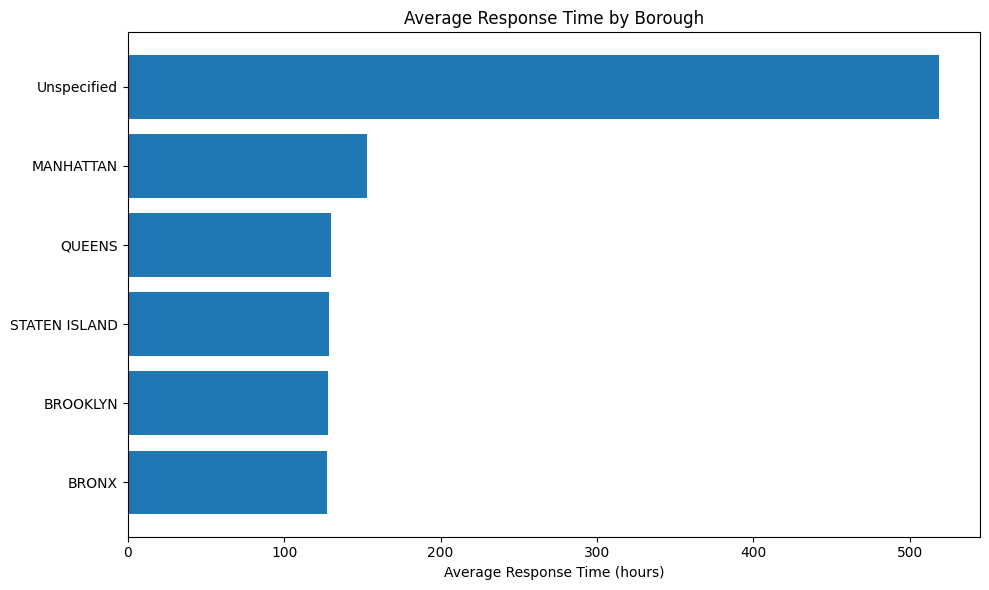

In [14]:
# 12. Borough performance

required = {"borough", "response_time_hours"}
if required.issubset(df.columns):
    borough_perf = (
        df.dropna(subset=["borough"])
          .groupby("borough")
          .agg(
              request_count=("borough", "size"),
              avg_response_hours=("response_time_hours", "mean"),
              median_response_hours=("response_time_hours", "median"),
          )
          .reset_index()
          .sort_values("request_count", ascending=False)
    )
    display(borough_perf)
    save_table(borough_perf, "borough_performance.csv")

    plt.figure(figsize=(10, 6))
    plot_df = borough_perf.sort_values("avg_response_hours", ascending=True)
    plt.barh(plot_df["borough"], plot_df["avg_response_hours"])
    plt.title("Average Response Time by Borough")
    plt.xlabel("Average Response Time (hours)")
    save_plot("avg_response_time_by_borough.png")
else:
    print("Required columns not available:", required)


,agency,request_count,avg_response_hours,median_response_hours
9,EDC,15876,6208.580062,6216.779167
14,TLC,31859,1484.942564,620.114861
4,DOE,1705,1476.230571,114.363056
12,OOS,2170,968.950811,999.651667
3,DOB,93587,713.837013,124.363333
7,DPR,96229,662.760785,144.624167
5,DOHMH,69462,449.865759,22.982917
13,OTI,168,384.673706,302.495833
0,DCWP,16367,377.642282,115.146111
10,HPD,759214,240.441084,76.105000


Saved: outputs_311_eda/agency_performance.csv
Saved: outputs_311_eda/agency_avg_response_time_top15.png


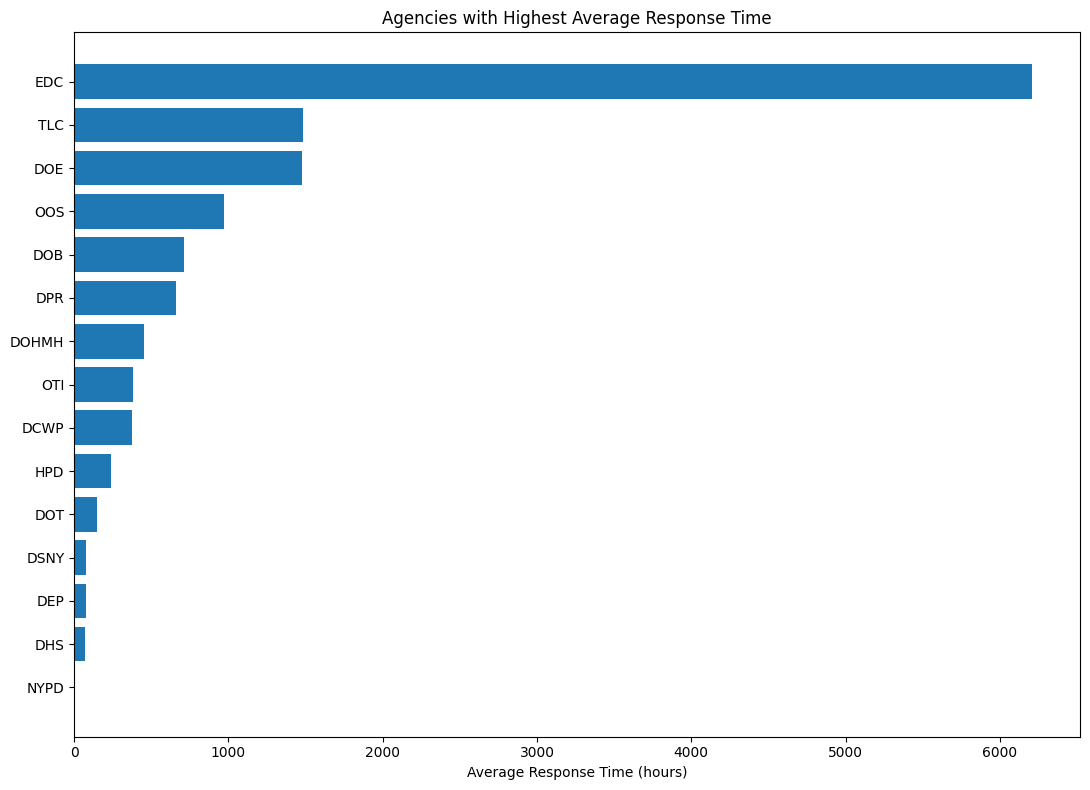

In [15]:
# 13. Agency performance

required = {"agency", "response_time_hours"}
if required.issubset(df.columns):
    agency_perf = (
        df.dropna(subset=["agency"])
          .groupby("agency")
          .agg(
              request_count=("agency", "size"),
              avg_response_hours=("response_time_hours", "mean"),
              median_response_hours=("response_time_hours", "median"),
          )
          .reset_index()
    )
    agency_perf = agency_perf[agency_perf["request_count"] >= 30].sort_values("avg_response_hours", ascending=False)
    display(agency_perf.head(20))
    save_table(agency_perf, "agency_performance.csv")

    plt.figure(figsize=(11, 8))
    plot_df = agency_perf.head(15).sort_values("avg_response_hours", ascending=True)
    plt.barh(plot_df["agency"], plot_df["avg_response_hours"])
    plt.title("Agencies with Highest Average Response Time")
    plt.xlabel("Average Response Time (hours)")
    save_plot("agency_avg_response_time_top15.png")
else:
    print("Required columns not available:", required)


,channel,request_count
0,ONLINE,1486559
1,PHONE,828511
2,MOBILE,726136
3,UNKNOWN,258790
4,OTHER,4


Saved: outputs_311_eda/channel_usage.csv
Saved: outputs_311_eda/channel_usage.png


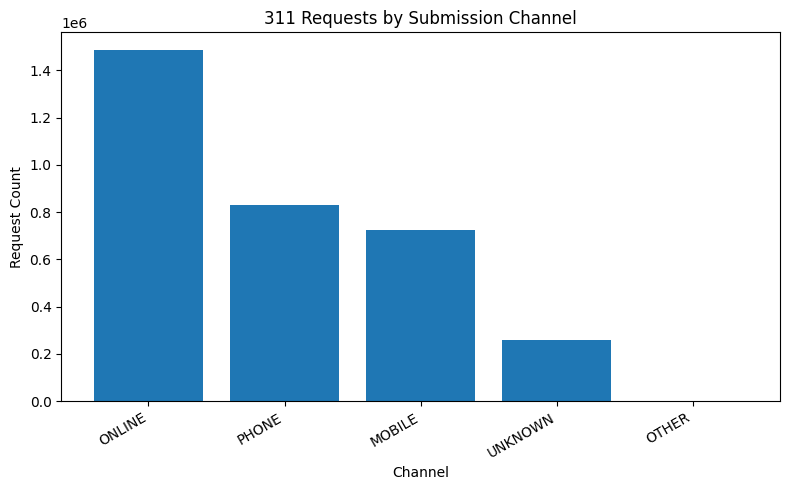

In [16]:
# 14. Channel adoption

if "open_data_channel_type" in df.columns:
    channel_df = (
        df["open_data_channel_type"]
        .fillna("Unknown")
        .value_counts()
        .reset_index()
    )
    channel_df.columns = ["channel", "request_count"]
    display(channel_df)
    save_table(channel_df, "channel_usage.csv")

    plt.figure(figsize=(8, 5))
    plt.bar(channel_df["channel"], channel_df["request_count"])
    plt.title("311 Requests by Submission Channel")
    plt.xlabel("Channel")
    plt.ylabel("Request Count")
    plt.xticks(rotation=30, ha="right")
    save_plot("channel_usage.png")
else:
    print("Column 'open_data_channel_type' not available.")


,created_month_name,request_count
0,January,348510
1,February,334687
2,March,341923
3,April,30827
4,May,32928
5,June,314976
6,July,315845
7,August,304009
8,September,302676
9,October,336611


Saved: outputs_311_eda/monthly_request_volume.csv
Saved: outputs_311_eda/monthly_request_volume.png


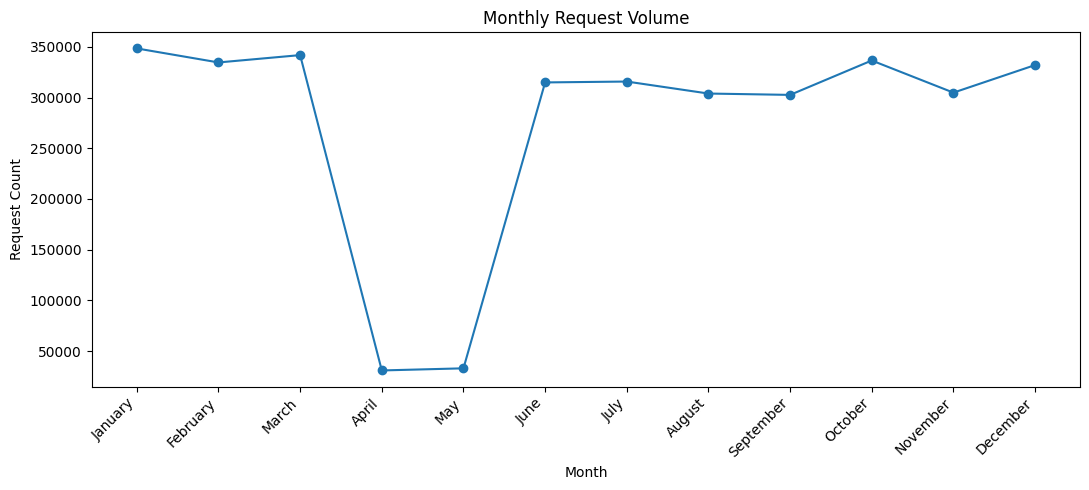

,created_dayofweek,request_count
0,Monday,508038
1,Tuesday,503543
2,Wednesday,483229
3,Thursday,474840
4,Friday,478010
5,Saturday,426976
6,Sunday,425364


Saved: outputs_311_eda/weekday_request_volume.csv


In [17]:
# 15. Time patterns

if {"created_date", "created_month_name"}.issubset(df.columns):
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]
    monthly = (
        df.groupby("created_month_name")
          .size()
          .reindex(month_order)
          .reset_index(name="request_count")
    )
    display(monthly)
    save_table(monthly, "monthly_request_volume.csv")

    plt.figure(figsize=(11, 5))
    plt.plot(monthly["created_month_name"], monthly["request_count"], marker="o")
    plt.title("Monthly Request Volume")
    plt.xlabel("Month")
    plt.ylabel("Request Count")
    plt.xticks(rotation=45, ha="right")
    save_plot("monthly_request_volume.png")

if {"created_dayofweek"}.issubset(df.columns):
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekday = (
        df.groupby("created_dayofweek")
          .size()
          .reindex(weekday_order)
          .reset_index(name="request_count")
    )
    display(weekday)
    save_table(weekday, "weekday_request_volume.csv")


In [18]:
# 16. Delay candidates and repeat complaint signals

if "delay_flag_due_date" in df.columns:
    delay_summary = (
        df.groupby("problem", dropna=False)["delay_flag_due_date"]
          .agg(["count", "mean"])
          .reset_index()
          .rename(columns={"count": "request_count", "mean": "delay_rate"})
          .sort_values(["request_count", "delay_rate"], ascending=[False, False])
    )
    display(delay_summary.head(20))
    save_table(delay_summary, "delay_rate_by_problem.csv")

if "possible_repeat_count" in df.columns:
    repeat_summary = (
        df[df["possible_repeat_count"] > 1]
        .groupby("problem", dropna=False)
        .size()
        .reset_index(name="repeat_candidate_rows")
        .sort_values("repeat_candidate_rows", ascending=False)
    )
    display(repeat_summary.head(20))
    save_table(repeat_summary, "repeat_complaint_candidates.csv")


,problem,request_count,delay_rate
85,Illegal Parking,501365,0.0
114,Noise - Residential,369414,0.0
73,HEAT/HOT WATER,329068,0.0
15,Blocked Driveway,161274,0.0
115,Noise - Street/Sidewalk,144663,0.0
174,UNSANITARY CONDITION,108095,0.0
156,Street Condition,82148,0.0
187,Water System,75661,0.0
125,PLUMBING,67233,0.0
150,Snow or Ice,63938,0.0


Saved: outputs_311_eda/delay_rate_by_problem.csv


,problem,repeat_candidate_rows
68,Illegal Parking,496381
95,Noise - Residential,361755
60,HEAT/HOT WATER,321417
15,Blocked Driveway,152378
96,Noise - Street/Sidewalk,134640
145,UNSANITARY CONDITION,99102
131,Street Condition,68159
157,Water System,63572
126,Snow or Ice,62085
105,PLUMBING,58628


Saved: outputs_311_eda/repeat_complaint_candidates.csv


In [19]:
# 17. Optional geospatial sanity check

if {"latitude", "longitude"}.issubset(df.columns):
    geo_df = df.dropna(subset=["latitude", "longitude"]).copy()
    print("Rows with valid latitude/longitude:", len(geo_df))
    display(geo_df[["latitude", "longitude", "borough", "problem"]].head())
else:
    print("Latitude / longitude fields not available.")


Rows with valid latitude/longitude: 3240301


,latitude,longitude,borough,problem
0,40.724443,-73.915105,QUEENS,Street Condition
1,40.741714,-73.906332,QUEENS,Street Condition
2,40.684240,-73.846095,QUEENS,Street Condition
3,40.728961,-73.984864,MANHATTAN,Graffiti
4,40.699938,-73.911808,BROOKLYN,Street Condition


In [26]:
# 18. Optional text exploration

# This is intentionally light. The project is primarily a structured-data
# operations project, but these fields can add depth if needed.

from collections import Counter
import re
import gc

# Colab-friendly throttling settings
# NLP_MAX_ROWS = 25000
# NLP_MAX_CHARS = 200

NLP_MAX_ROWS = 3500000       # try 25000 if RAM is still tight
NLP_MAX_CHARS = 500        # truncate long text entries
NLP_TOP_N = 30
NLP_RANDOM_SAMPLE = True
NLP_RANDOM_STATE = 42

text_col = None
for candidate in ["resolution_description", "additional_details", "problem_detail"]:
    if candidate in df.columns:
        text_col = candidate
        break

if text_col:
    text_series = df[text_col].dropna().astype(str)

    # Limit rows to reduce memory pressure
    if len(text_series) > NLP_MAX_ROWS:
        if NLP_RANDOM_SAMPLE:
            text_series = text_series.sample(NLP_MAX_ROWS, random_state=NLP_RANDOM_STATE)
        else:
            text_series = text_series.iloc[:NLP_MAX_ROWS]

    # Normalize and truncate text so very long rows do not dominate RAM
    text_series = text_series.str.lower().str.slice(0, NLP_MAX_CHARS)

    token_counter = Counter()

    for text in text_series:
        cleaned = re.sub(r"[^a-z0-9\s]", " ", text)
        tokens = cleaned.split()
        token_counter.update(tokens)

    token_counts = pd.DataFrame(
        token_counter.most_common(NLP_TOP_N),
        columns=["token", "count"]
    )

    display(token_counts)
    save_table(token_counts, f"top_tokens_{text_col}.csv")

    # Light cleanup
    del text_series, token_counter
    gc.collect()
else:
    print("No suitable text column found for light NLP exploration.")

,token,count
0,the,11817155
1,to,6474590
2,complaint,4335290
3,of,2785856
4,and,2679834
5,a,2598557
6,department,2495177
7,if,2455681
8,condition,1844757
9,police,1741003


Saved: outputs_311_eda/top_tokens_resolution_description.csv


In [27]:
# Final Step: Zip Outputs Folder

import shutil

# Name of the folder created earlier in the notebook
output_folder = "outputs_311_eda"

# Create zip file
shutil.make_archive(output_folder, 'zip', output_folder)

print(f"Zipped folder created: {output_folder}.zip")

Zipped folder created: outputs_311_eda.zip
